# PRCP-1003 - Customer Transaction Prediction

**Project:** Customer Transaction Prediction  
**Domain:** Banking  
**Candidate:** Ravi Kumar/Jackson/Bindhu  

## Problem Statement

The objective of this project is to build a predictive model that helps the bank identify which customers are likely to make a transaction in the future.

The dataset contains anonymized customer features. Since the actual feature names are not available, the focus of this project is mainly on data preparation, model building, model comparison, and final production recommendation.

## Project Tasks

1. Prepare a complete data analysis report on the given data.
2. Create a predictive model to identify customers who will make a transaction in the future.
3. Compare multiple models and suggest the best model for production.
4. Document the challenges faced and the techniques used to handle them.

## 1. Import Required Libraries

In this section, we import all required Python libraries.

### Simple Explanation

- `pandas` helps us read and process the dataset.
- `numpy` helps with numerical calculations.
- `matplotlib` and `seaborn` help us create charts.
- `sklearn` helps us build machine learning models and evaluate their performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The dataset has the following structure:

- `ID_code`: Unique customer ID
- `target`: Prediction column
    - `0` means the customer will not make a transaction
    - `1` means the customer will make a transaction
- `var_0` to `var_199`: Anonymized customer features

### Simple Explanation

The features are anonymized, so we cannot explain what each feature means in business terms.  
However, we can still use them to build a strong prediction model.

In [ ]:
# Update this path only if your files are stored in a different folder
project_path = r"E:\Capstone Project\Customer Transaction Prediction (PRCP-1003)"

# The downloaded file may be named train.csv or train(1).csv
possible_files = [
    os.path.join(project_path, "train(1).csv"),
    "train.csv",
    "train(1).csv"
]

train_file = None

for file in possible_files:
    if os.path.exists(file):
        train_file = file
        break

if train_file is None:
    raise FileNotFoundError("Training file not found. Please keep train.csv or train(1).csv in the project folder.")

df = pd.read_csv(train_file)

print("Dataset loaded successfully.")
print("File used:", train_file)
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
File used: E:\Capstone Project\Customer Transaction Prediction (PRCP-1003)\train(1).csv
Dataset Shape: (200000, 202)


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,...,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,2.9252,3.1821,14.0137,...,5.8764,11.8411,-19.7159,17.5743,0.5857,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,-0.4032,8.0585,14.0239,...,-4.8622,7.6543,-15.9319,13.3175,-0.3566,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,-0.3249,-11.2648,14.1929,...,-5.3000,5.3745,-6.2660,10.1934,-0.8417,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,2.3061,2.8102,13.8463,...,-0.0498,7.9336,-12.8279,12.4124,1.8489,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,-9.4458,-12.1419,13.8481,...,-7.8931,6.4209,5.9270,16.0201,-0.2829,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


## 3. Dataset Overview

Here, we understand the basic structure of the dataset.

### Simple Explanation

This helps us confirm:
- Number of rows and columns
- Column names
- Data types
- Whether the dataset has loaded correctly

In [3]:
print("Dataset Shape:", df.shape)

print()
print("First 5 Records:")
display(df.head())

print()
print("Dataset Information:")
df.info()

print()
print("Column Names:")
print(df.columns.tolist()[:15], "...")

Dataset Shape: (200000, 202)

First 5 Records:


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,...,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,2.9252,3.1821,14.0137,...,5.8764,11.8411,-19.7159,17.5743,0.5857,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,-0.4032,8.0585,14.0239,...,-4.8622,7.6543,-15.9319,13.3175,-0.3566,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,-0.3249,-11.2648,14.1929,...,-5.3000,5.3745,-6.2660,10.1934,-0.8417,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,2.3061,2.8102,13.8463,...,-0.0498,7.9336,-12.8279,12.4124,1.8489,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,-9.4458,-12.1419,13.8481,...,-7.8931,6.4209,5.9270,16.0201,-0.2829,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB

Column Names:
['ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8', 'var_9', 'var_10', 'var_11', 'var_12'] ...


## 4. Missing Value Check

Before model building, we check if there are any missing values.

### Simple Explanation

Missing values can create problems during model training.  
If missing values exist, we need to handle them using suitable techniques.

In [4]:
missing_values = df.isnull().sum()
total_missing = missing_values.sum()

print("Total Missing Values:", total_missing)

if total_missing > 0:
    print("Columns with missing values:")
    display(missing_values[missing_values > 0].sort_values(ascending=False))
else:
    print("No missing values found in the dataset.")

Total Missing Values: 0
No missing values found in the dataset.


## 5. Duplicate Record Check

Duplicate records can affect model quality.

### Simple Explanation

If the same record appears multiple times, the model may become biased.  
So, we check whether duplicate rows exist.

In [5]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
    print("New Dataset Shape:", df.shape)
else:
    print("No duplicate records found.")

Duplicate Rows: 0
No duplicate records found.


## 6. Target Variable Analysis

The target column tells us whether a customer will make a transaction.

- `0`: Customer will not make a transaction
- `1`: Customer will make a transaction

### Simple Explanation

This is a classification problem because the output has two categories: 0 and 1.

,Count,Percentage
target,,
0,179902,89.95
1,20098,10.05


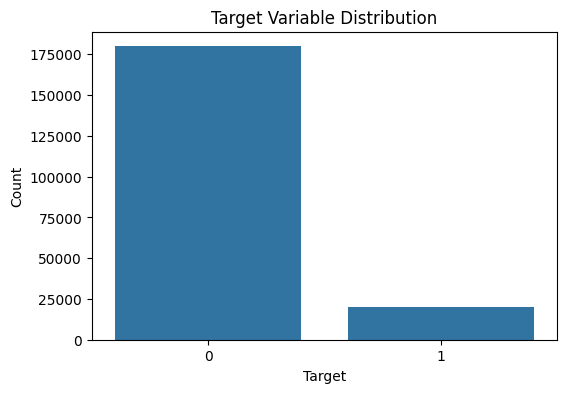

In [6]:
target_counts = df["target"].value_counts()
target_percentage = df["target"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentage.round(2)
})

display(target_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")
plt.title("Target Variable Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

## 7. Observation on Class Imbalance

In banking transaction prediction datasets, usually the number of customers who do not transact is much higher than the number of customers who transact.

### Simple Explanation

If the target class is imbalanced, accuracy alone can be misleading.  
So, we also use metrics like:

- Precision
- Recall
- F1 Score
- ROC-AUC Score

These metrics give a better understanding of model performance.

In [7]:
negative_class = target_counts.get(0, 0)
positive_class = target_counts.get(1, 0)

imbalance_ratio = negative_class / positive_class if positive_class != 0 else np.nan

print("Non-Transaction Customers:", negative_class)
print("Transaction Customers:", positive_class)
print("Imbalance Ratio:", round(imbalance_ratio, 2))

Non-Transaction Customers: 179902
Transaction Customers: 20098
Imbalance Ratio: 8.95


## 8. Feature and Target Separation

Now we separate the independent variables and dependent variable.

### Simple Explanation

- `X` contains the input features used for prediction.
- `y` contains the target column that we want to predict.

We remove `ID_code` because it is only an identifier and does not help in prediction.

In [8]:
X = df.drop(columns=["ID_code", "target"])
y = df["target"]

print("Feature Data Shape:", X.shape)
print("Target Data Shape:", y.shape)

display(X.head())

Feature Data Shape: (200000, 200)
Target Data Shape: (200000,)


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,...,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,2.9252,3.1821,14.0137,0.5745,8.7989,...,5.8764,11.8411,-19.7159,17.5743,0.5857,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,-0.4032,8.0585,14.0239,8.4135,5.4345,...,-4.8622,7.6543,-15.9319,13.3175,-0.3566,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,-0.3249,-11.2648,14.1929,7.3124,7.5244,...,-5.3000,5.3745,-6.2660,10.1934,-0.8417,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,2.3061,2.8102,13.8463,11.9704,6.4569,...,-0.0498,7.9336,-12.8279,12.4124,1.8489,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,-9.4458,-12.1419,13.8481,7.8895,7.7894,...,-7.8931,6.4209,5.9270,16.0201,-0.2829,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


## 9. Train-Test Split

The data is split into training and testing sets.

### Simple Explanation

- Training data is used to train the model.
- Testing data is used to check how well the model performs on unseen data.

We use stratified splitting so that both train and test sets maintain the same target class distribution.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (160000, 200)
X_test Shape: (40000, 200)
y_train Shape: (160000,)
y_test Shape: (40000,)


## 10. Model Building Plan

We compare multiple models:

1. Logistic Regression
2. Random Forest Classifier
3. Hist Gradient Boosting Classifier

### Why These Models?

- **Logistic Regression** is simple and works well as a baseline model.
- **Random Forest** can capture non-linear patterns.
- **Hist Gradient Boosting** is powerful for tabular data and often performs well on structured datasets.

### Simple Explanation

We compare different models so that we can select the best model for production instead of depending on only one algorithm.

In [10]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Hist Gradient Boosting Classifier": HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.05,
        random_state=42
    )
}

print("Models created successfully.")

Models created successfully.


## 11. Model Training and Evaluation

We train each model and evaluate the performance.

### Evaluation Metrics Used

- **Accuracy:** Overall correct predictions
- **Precision:** Out of predicted transaction customers, how many actually transacted
- **Recall:** Out of actual transaction customers, how many were correctly identified
- **F1 Score:** Balance between precision and recall
- **ROC-AUC:** Overall ranking ability of the model

### Simple Explanation

For this project, ROC-AUC and recall are very important because the bank wants to identify customers who are likely to transact.

In [11]:
model_results = []
trained_models = {}

for model_name, model in models.items():
    print("Training:", model_name)

    model.fit(X_train, y_train)
    trained_models[model_name] = model

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

model_results_df = pd.DataFrame(model_results).sort_values(by="ROC-AUC", ascending=False)

display(model_results_df)

Training: Logistic Regression
Training: Random Forest Classifier
Training: Hist Gradient Boosting Classifier


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.783400,0.286542,0.775373,0.418445,0.859900
2,Hist Gradient Boosting Classifier,0.900675,0.885246,0.013433,0.026464,0.844508
1,Random Forest Classifier,0.859925,0.343546,0.432338,0.382862,0.791294


## 12. Model Comparison Report

This report compares all models based on key classification metrics.

### Simple Explanation

The best model should not be selected only based on accuracy.  
Since the dataset is imbalanced, ROC-AUC, recall, and F1 score are more useful.

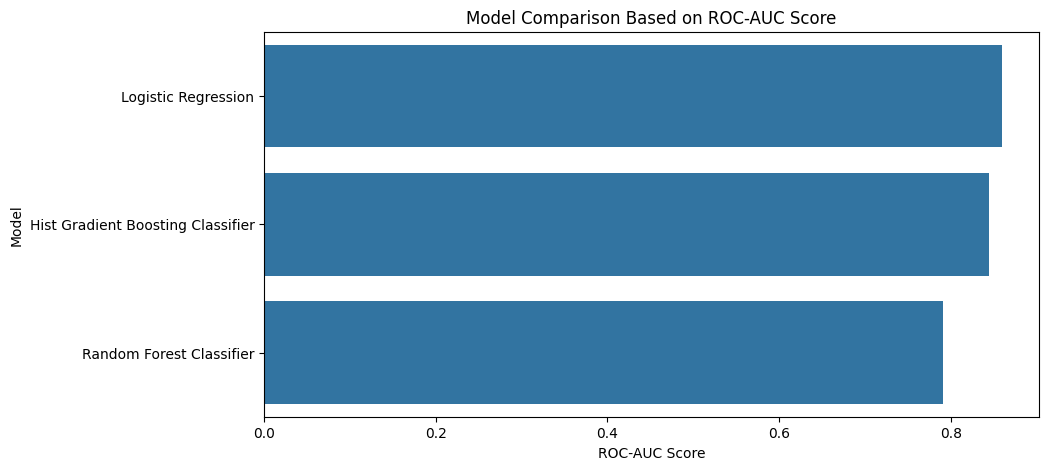

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.783400,0.286542,0.775373,0.418445,0.859900
2,Hist Gradient Boosting Classifier,0.900675,0.885246,0.013433,0.026464,0.844508
1,Random Forest Classifier,0.859925,0.343546,0.432338,0.382862,0.791294


In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(data=model_results_df, x="ROC-AUC", y="Model")
plt.title("Model Comparison Based on ROC-AUC Score")
plt.xlabel("ROC-AUC Score")
plt.ylabel("Model")
plt.show()

display(model_results_df)

## 13. Best Model Selection

The best model is selected mainly based on ROC-AUC score.

### Simple Explanation

ROC-AUC is useful because it checks how well the model separates customers who will transact from those who will not transact.

In [13]:
best_model_name = model_results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model Selected:", best_model_name)
display(model_results_df.iloc[[0]])

Best Model Selected: Logistic Regression


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7834,0.286542,0.775373,0.418445,0.8599


## 14. Confusion Matrix for Best Model

The confusion matrix shows how many predictions were correct and incorrect.

### Simple Explanation

It helps us understand:
- True Negatives: Correctly predicted non-transaction customers
- True Positives: Correctly predicted transaction customers
- False Positives: Predicted transaction, but actually no transaction
- False Negatives: Predicted no transaction, but actually transaction

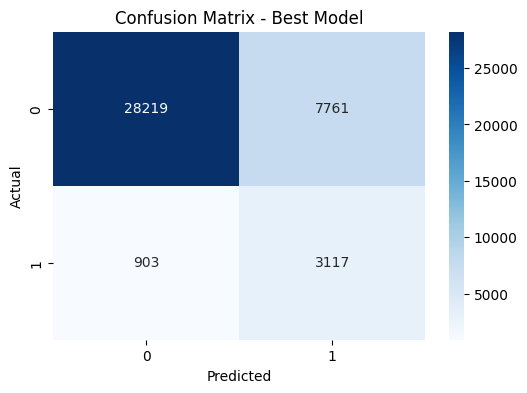

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     35980
           1       0.29      0.78      0.42      4020

    accuracy                           0.78     40000
   macro avg       0.63      0.78      0.64     40000
weighted avg       0.90      0.78      0.82     40000



In [14]:
best_y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report:")
print(classification_report(y_test, best_y_pred, zero_division=0))

## 15. ROC Curve for Best Model

The ROC curve shows the model's ability to separate the two target classes.

### Simple Explanation

A model with a curve closer to the top-left corner performs better.

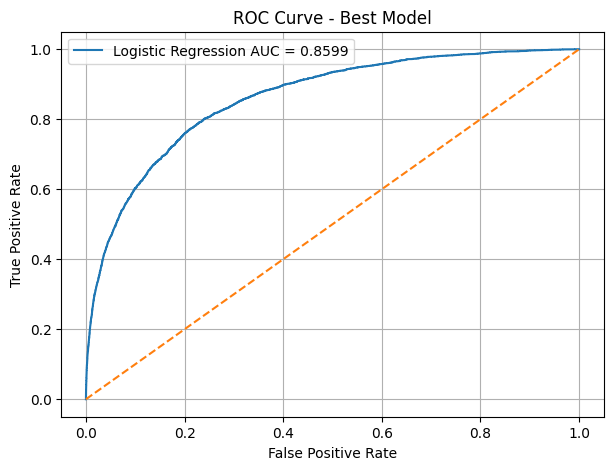

In [15]:
if hasattr(best_model, "predict_proba"):
    best_y_proba = best_model.predict_proba(X_test)[:, 1]
else:
    best_y_proba = best_y_pred

fpr, tpr, thresholds = roc_curve(y_test, best_y_proba)
best_auc = roc_auc_score(y_test, best_y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} AUC = {best_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Best Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

## 16. Feature Importance

Since the features are anonymized, we cannot explain the business meaning of each feature.  
However, we can still identify which variables are most useful for prediction.

### Simple Explanation

Feature importance helps us understand which variables are contributing more to the model's decisions.

,Feature,Importance
81,var_81,0.242971
139,var_139,0.229305
6,var_6,0.216838
12,var_12,0.210113
53,var_53,0.207932
110,var_110,0.205344
76,var_76,0.205321
146,var_146,0.199602
174,var_174,0.195328
26,var_26,0.195059


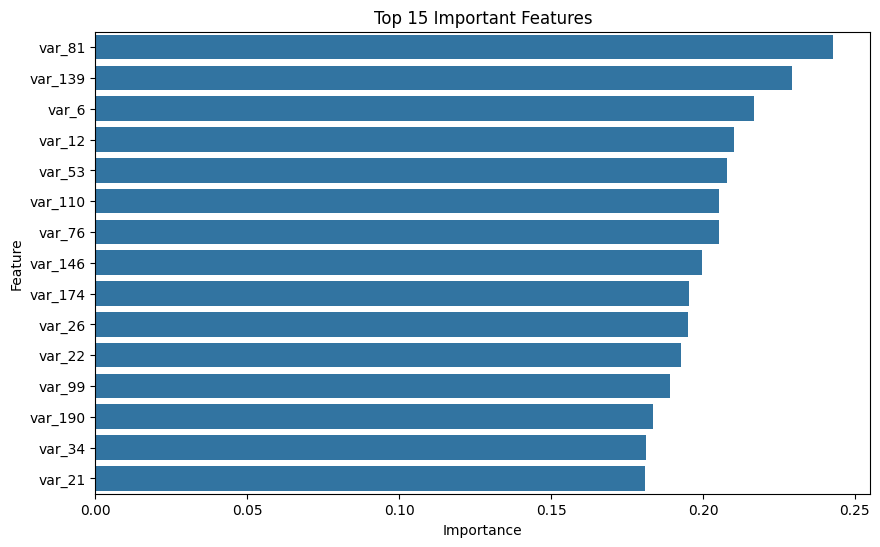

In [16]:
feature_importance_df = None

if best_model_name == "Random Forest Classifier":
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

elif best_model_name == "Logistic Regression":
    coefficients = best_model.named_steps["model"].coef_[0]
    feature_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": np.abs(coefficients)
    }).sort_values(by="Importance", ascending=False)

else:
    print("The selected model does not provide direct feature importance.")
    print("For production, permutation importance can be used separately if needed.")

if feature_importance_df is not None:
    display(feature_importance_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df.head(15), x="Importance", y="Feature")
    plt.title("Top 15 Important Features")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

## 17. Prediction on New Customer Data

In real banking use, the trained model can be used to predict whether a new customer will make a transaction.

### Simple Explanation

The model returns:
- `0`: Customer is not likely to make a transaction
- `1`: Customer is likely to make a transaction

If probability is available, the bank can also rank customers based on likelihood.

In [17]:
sample_customer = X_test.iloc[[0]]

sample_prediction = best_model.predict(sample_customer)[0]

if hasattr(best_model, "predict_proba"):
    sample_probability = best_model.predict_proba(sample_customer)[0][1]
else:
    sample_probability = None

print("Sample Prediction:", sample_prediction)

if sample_probability is not None:
    print("Transaction Probability:", round(sample_probability, 4))

Sample Prediction: 0
Transaction Probability: 0.039


## 18. Production Recommendation

Based on the model comparison, the best model should be selected for production using ROC-AUC score, recall, and F1 score.

### Recommendation

The selected model can help the bank identify customers who are more likely to make a future transaction.

### How the Bank Can Use This Model

1. Target high-probability customers for marketing campaigns.
2. Reduce unnecessary campaign cost by avoiding low-probability customers.
3. Improve customer engagement using data-driven targeting.
4. Use probability scores to prioritize customers.
5. Retrain the model regularly with updated transaction data.

## 19. Challenges Faced and Techniques Used

### Challenge 1: Anonymized Features

The dataset contains 200 anonymized features, so the real business meaning of each feature is not known.

**Technique Used:**  
Focused on statistical and machine learning performance rather than business interpretation of individual variables.

### Challenge 2: Class Imbalance

The number of customers who do not make transactions is usually much higher than the number of customers who make transactions.

**Technique Used:**  
Used stratified train-test split and evaluated the model using ROC-AUC, precision, recall, and F1 score instead of accuracy alone.

### Challenge 3: High Number of Features

The dataset contains 200 feature columns.

**Technique Used:**  
Used machine learning models that can handle many numerical features. Feature importance was also checked for model understanding.

### Challenge 4: ID Column Not Useful for Prediction

`ID_code` is only a unique identifier.

**Technique Used:**  
Removed `ID_code` before model training.

### Challenge 5: Model Selection

Different models perform differently on the same data.

**Technique Used:**  
Compared Logistic Regression, Random Forest, and Hist Gradient Boosting using the same train-test split and evaluation metrics.

## 20. Final Conclusion

This project created a machine learning solution for customer transaction prediction in the banking domain.

The dataset contained anonymized features and a binary target column.  
After checking data quality and target distribution, the data was split into training and testing sets using stratified sampling.

Multiple models were trained and compared, including Logistic Regression, Random Forest Classifier, and Hist Gradient Boosting Classifier.  
The best model was selected based on ROC-AUC score and supporting classification metrics.

This model can help the bank identify customers who are more likely to make transactions in the future.  
It can also support marketing campaign planning, customer targeting, and cost optimization.

Overall, this project shows how machine learning can help banks make better data-driven decisions.